<a href="https://colab.research.google.com/github/angioitoan2409/flood_forecasting/blob/main/getting_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2.1.0
20995 building footprints found


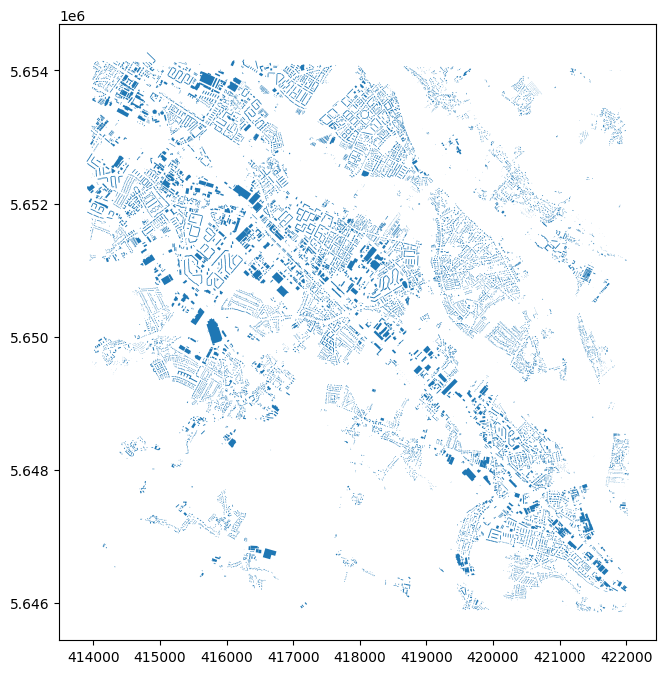

In [ ]:
# In Colab
!pip install osmnx geopandas -q

import osmnx as ox
import geopandas as gpd

print(ox.__version__)  # check version — call signature below matches osmnx >=1.9

north, south, east, west = 51.032250, 50.959185, 13.889340, 13.773558

buildings = ox.features_from_bbox(bbox=(west, south, east, north), tags={"building": True})

# Reproject to match your DEM/sealing CRS
buildings = buildings.to_crs("EPSG:25833")
buildings = buildings[buildings.geometry.type.isin(["Polygon", "MultiPolygon"])]

print(len(buildings), "building footprints found")
buildings.plot(figsize=(8,8))  # quick visual sanity check

buildings.to_file("/content/drive/MyDrive/flood_forecasting/data/building/buildings_osm.gpkg", driver="GPKG")